In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import akshare as ak
import matplotlib.dates as mdates

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def calc_price_bias(series: pd.Series, n: int = 20):
    ma = series.rolling(window=n).mean()
    bias = (series - ma) / ma
    return bias

def calc_momentum(series: pd.Series, n: int = 20):
    return series / series.shift(n) - 1

In [3]:
def plot_box(results_dict: dict, bench_sharpe: float, title: str = "夏普比率分布"):
    df_plot = pd.DataFrame(results_dict)

    plt.figure(figsize=(12, 7))

    df_plot.boxplot(grid=False,
                    patch_artist=False,
                    medianprops={'color': 'green', 'linewidth': 1.5},
                    showmeans=False)

    plt.axhline(y=bench_sharpe, color='r', linestyle='--', label='Benchmark (Buy & Hold)')

    plt.title(title, fontsize=14)
    plt.ylabel('Sharpe Ratio', fontsize=12)
    plt.xlabel('Strategy / Factor Window', fontsize=12)
    plt.ylim(-1.5, 1.5)

    plt.xticks(rotation=45)

    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_cum_result(df: pd.DataFrame):
    fig, ax1 = plt.subplots()

    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax1.plot(df['日期'], df['cum_return'])

    ax2 = ax1.twinx()
    ax2.plot(df['日期'], df['benchmark'], 'r-')

    y_min = min(df['cum_return'].min(), df['benchmark'].min())
    y_min *= 1.05
    y_max = max(df['cum_return'].max(), df['benchmark'].max())
    y_max *= 1.05

    ax1.set_ylim(y_min, y_max)
    ax2.set_ylim(ax1.get_ylim())

In [4]:
class StrategyBackTester:
    def __init__(self, strategy_name: str, start_date: str = '20100101', end_date: str = '20250101'):
        self.start_date = start_date
        self.end_date = end_date
        self.strategy_name = strategy_name
        self.rolling_window = [10, 20, 60, 120]
        self.lookback_window = range(20, 60)
        self.data = self._get_daily_index_data()

    def _get_daily_index_data(self):
        data = ak.index_zh_a_hist(
            symbol='000300',
            start_date=self.start_date,
            end_date=self.end_date
        )

        data['日期'] = pd.to_datetime(data['日期'])
        data['market_return'] = data['收盘'].pct_change()
        data.dropna(inplace=True)
        data['benchmark'] = (1 + data['market_return']).cumprod()

        return data

    def _calc_rolling_indicators(self, series: pd.Series, indicator_name: str, indicator_calculator) -> pd.DataFrame:
        result = pd.DataFrame(index=series.index)

        for n in self.rolling_window:
            result[f"{indicator_name}_{n}"] = indicator_calculator(series, n)

        return result

    @property
    def sharpe_benchmark(self):
        bench_df = self.data[['market_return']].dropna()
        sharpe_series = self._calc_sharpe_ratio(bench_df)
        return sharpe_series.iloc[0]

    @staticmethod
    def boll_strategy(indicator: pd.Series, window):
        k = 2

        mb = indicator.rolling(window=window).mean()
        std = indicator.rolling(window=window).std()
        up = mb + k * std
        dn = mb - k * std

        buy_signal = indicator > up
        exit_signal = indicator < dn

        _signal = pd.Series(np.nan, index=indicator.index)
        _signal[buy_signal] = 1
        _signal[exit_signal] = -1

        _signal = _signal.ffill().fillna(0)

        return _signal

    @staticmethod
    def sma_strategy(indicator: pd.Series, window: int):
        ma_indicator = indicator.rolling(window=window).mean()

        _signal = pd.Series(0, index=indicator.index)
        _signal[indicator > ma_indicator] = 1
        _signal[indicator < ma_indicator] = -1

        _signal[ma_indicator.isna()] = 0
        return _signal

    @staticmethod
    def mom_strategy(indicator: pd.Series, window: int):
        past_indicator = indicator.shift(window)

        _signal = pd.Series(0, index=indicator.index)
        _signal[indicator > past_indicator] = 1
        _signal[indicator < past_indicator] = -1

        _signal[past_indicator.isna()] = 0
        return _signal

    def run_strategy(self, field_name: str, indicator_name: str, indicator_calculator):
        series = self.data[field_name]
        indicators = self._calc_rolling_indicators(series, indicator_name, indicator_calculator)

        _results = {}

        method = getattr(self, f"{self.strategy_name}_strategy")

        for n in self.rolling_window:
            signals = pd.DataFrame()

            indicator_index = f"{indicator_name}_{n}"
            indicator = indicators[indicator_index]

            for window in self.lookback_window:
                signals[window] = method(indicator, window)

            return_df = self._calc_return(signals)
            reverse_return_df = self._calc_return(-signals)

            _results[indicator_index.upper()] = self._calc_sharpe_ratio(return_df)
            _results[f"R{indicator_index.upper()}"] = self._calc_sharpe_ratio(reverse_return_df)

        return _results

    def _calc_return(self, signals: pd.DataFrame) -> pd.DataFrame:
        signals = signals.copy()

        trade_signal = signals.shift(1).fillna(0)

        return trade_signal.multiply(self.data['market_return'], axis=0)

    @staticmethod
    def _calc_sharpe_ratio(df: pd.DataFrame, rf=0.02) -> pd.Series:
        excess_returns = df - (rf / 252)

        mean_excess = excess_returns.mean()
        std_excess = excess_returns.std()

        sharpe = (mean_excess / std_excess) * (252 ** 0.5)

        return sharpe

  0%|          | 0/17 [00:00<?, ?it/s]

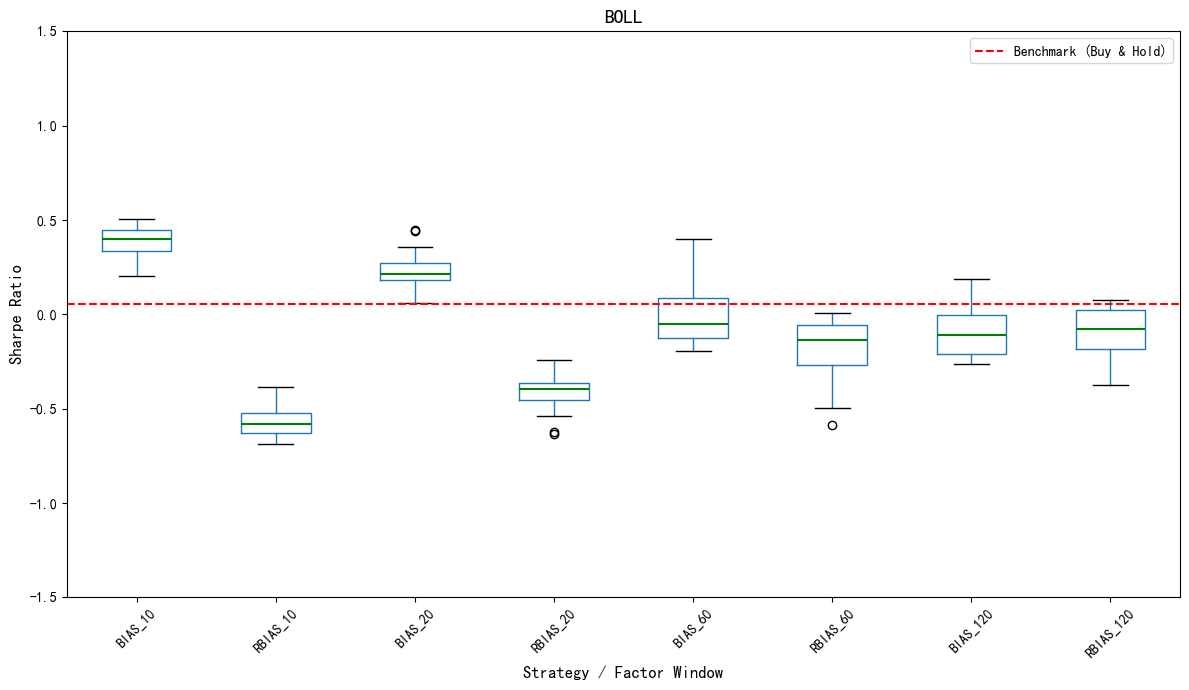

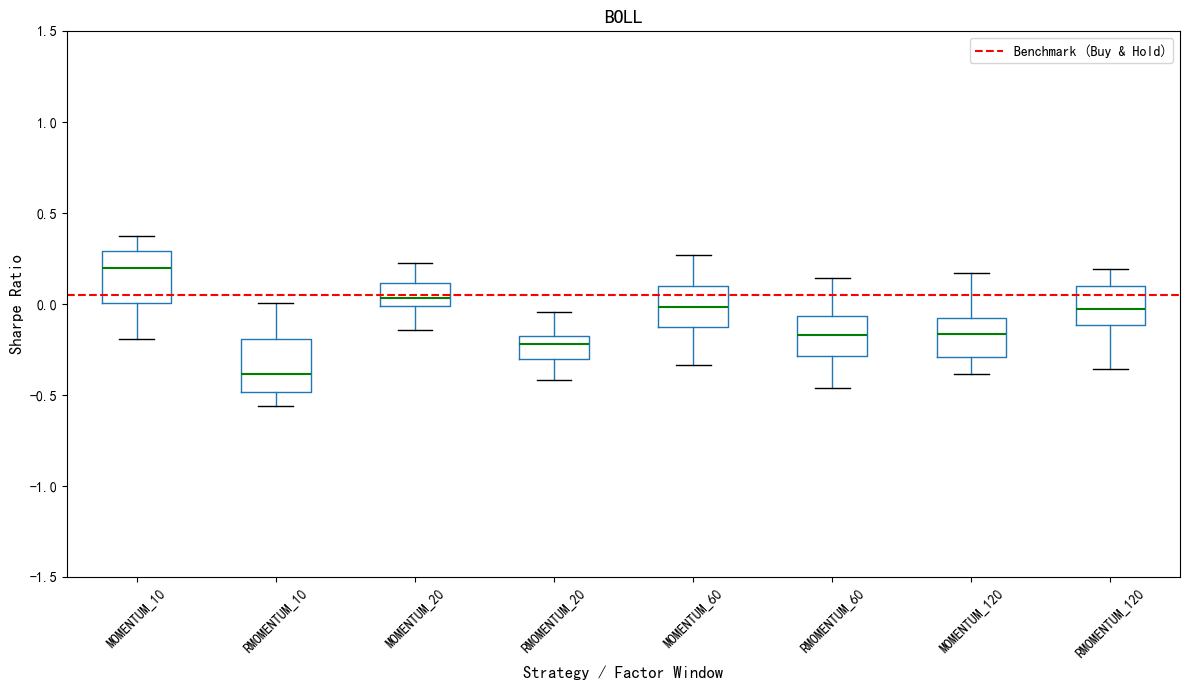

In [5]:
bt = StrategyBackTester('boll')
bias_results = bt.run_strategy("收盘", 'bias', calc_price_bias)
momentum_results = bt.run_strategy("收盘", 'momentum', calc_momentum)
plot_box(bias_results, bt.sharpe_benchmark, "BOLL")
plot_box(momentum_results, bt.sharpe_benchmark, "BOLL")

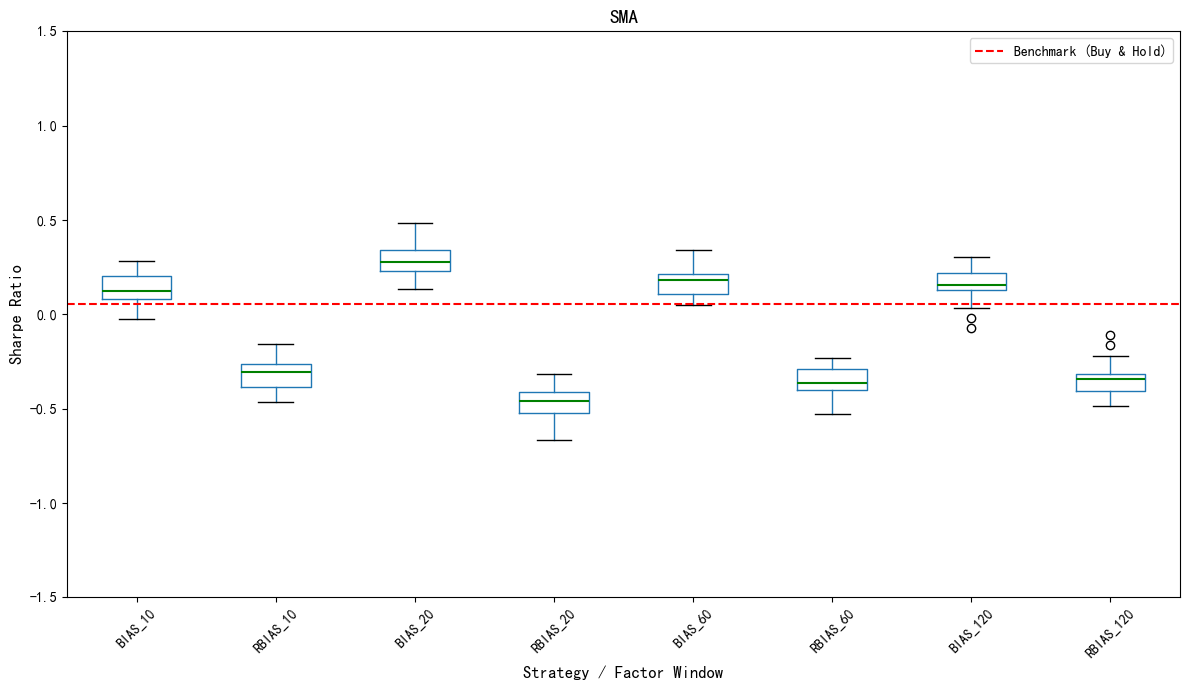

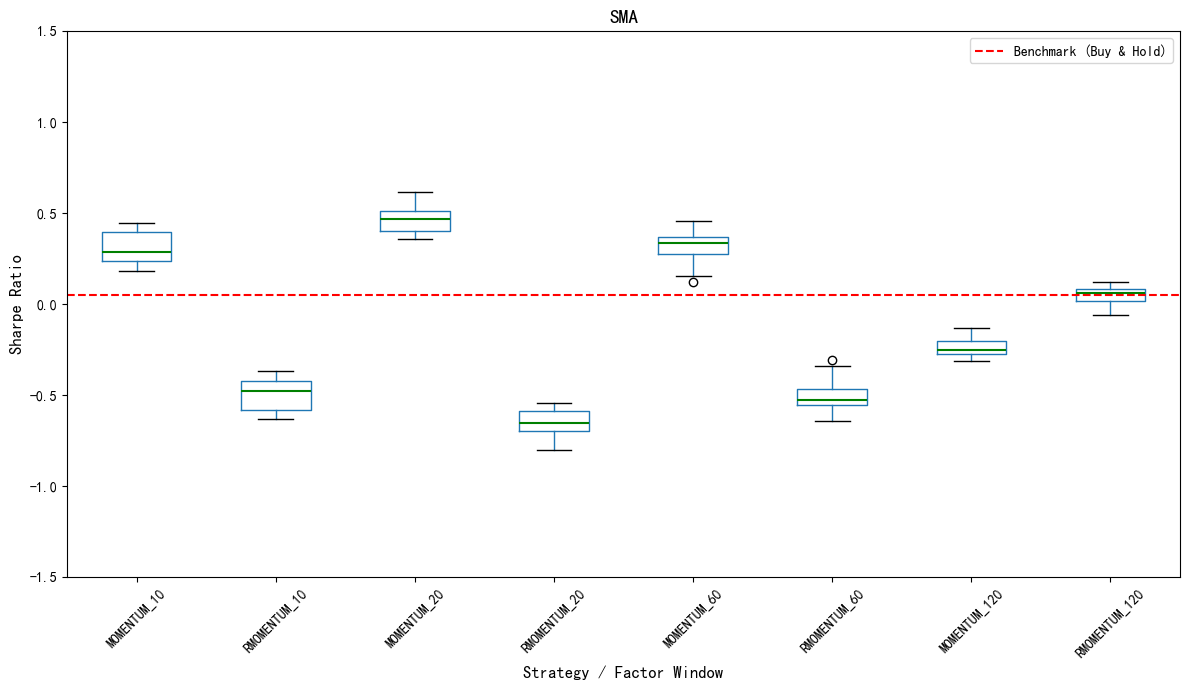

In [6]:
bt = StrategyBackTester('sma')
bias_results = bt.run_strategy("收盘", 'bias', calc_price_bias)
momentum_results = bt.run_strategy("收盘", 'momentum', calc_momentum)

plot_box(bias_results, bt.sharpe_benchmark, "SMA")
plot_box(momentum_results, bt.sharpe_benchmark, "SMA")

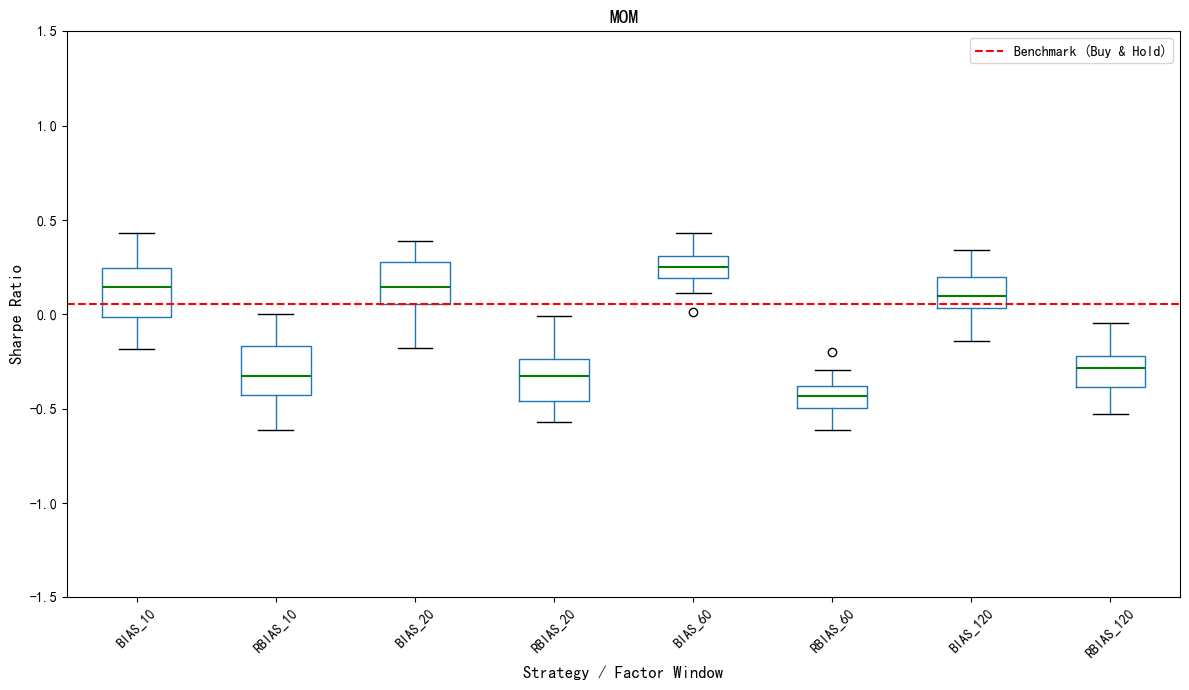

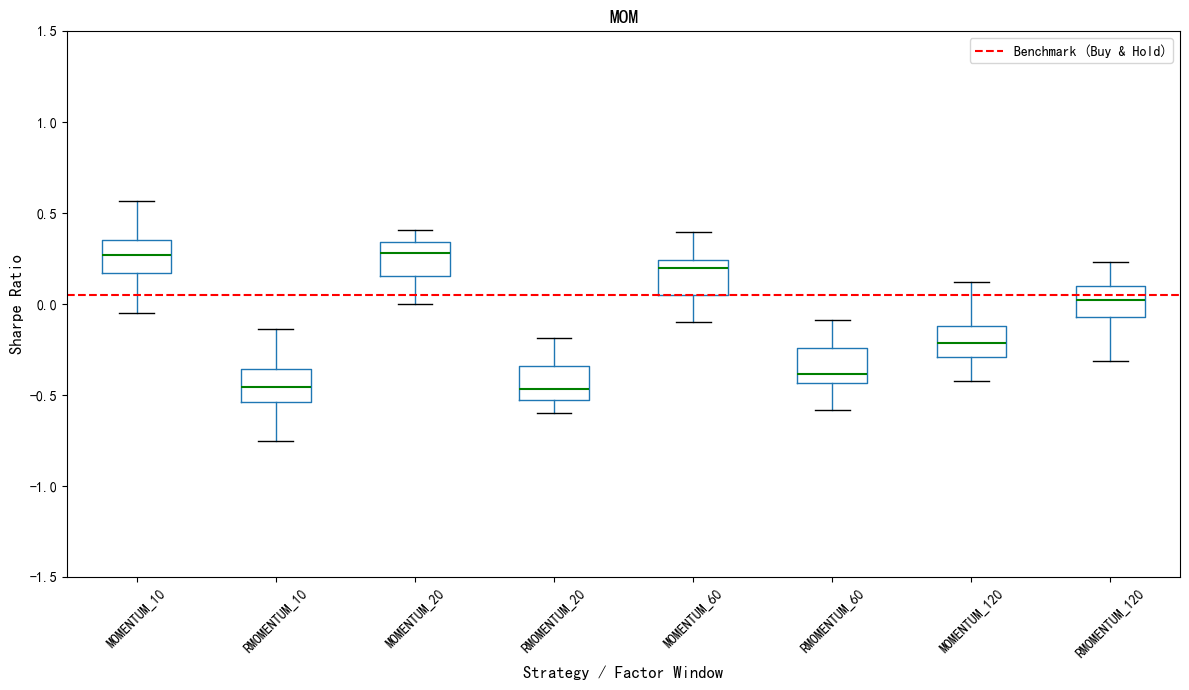

In [7]:
bt = StrategyBackTester('mom')
bias_results = bt.run_strategy("收盘", 'bias', calc_price_bias)
momentum_results = bt.run_strategy("收盘", 'momentum', calc_momentum)
plot_box(bias_results, bt.sharpe_benchmark, "MOM")
plot_box(momentum_results, bt.sharpe_benchmark, "MOM")